Multilingual Characterization and Extraction of Narratives
from Online News
--

Author: Manuel Carlucci

Student ID: 855237

Email: m.carlucci69@studenti.uniba.it

In [ ]:
!jupyter nbconvert --to html "/content/Manuel_Carlucci_Subtask1.ipynb" --log-level=ERROR

Subtask 1: Entity Framing
--
Given a news article and a list of mentions of named entities (NEs) in the article, assign for each such mention one or more roles using a predefined taxonomy of fine-grained roles covering three main type of roles: protagonists, antagonists, and innocent. This is a multi-label multi-class text-span classification task

Analyze Data
---


In [1]:
from google.colab import drive
drive.mount('/content/drive')

# - paths -
BASE = '/content/drive/MyDrive/NLP_Project'

TRAIN_ANNOTATIONS = f'{BASE}/training/EN/subtask-1-annotations.txt'
TRAIN_DOCS_DIR    = f'{BASE}/training/EN/raw-documents'
TEST_MENTIONS     = f'{BASE}/test/EN/subtask-1-entity-mentions.txt'
TEST_DOCS_DIR     = f'{BASE}/test/EN/subtask-1-documents'
GOLD_FILE         = f'{BASE}/test/EN/subtask-1-annotations.txt'
SCORER_SCRIPT     = f'{BASE}/subtask1_scorer.py'
OUTPUT_FILE       = f'{BASE}/predictions_subtask1_EN.txt'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Analysing: /content/drive/MyDrive/NLP_Project/training/EN/subtask-1-annotations.txt

 ---- Main roles ---- 
  Main Role  Count
 Antagonist    477
Protagonist    130
   Innocent     79

 ---- Fine-grained roles ----
Fine-Grained Role  Count
      Conspirator     79
       Instigator     70
         Deceiver     66
          Corrupt     63
           Victim     60
      Incompetent     60
           Tyrant     53
         Guardian     47
Foreign Adversary     46
        Terrorist     28
         Saboteur     24
         Virtuous     23
            Rebel     22
            Bigot     20
       Peacemaker     18
         Underdog     15
           Martyr     14
          Traitor     14
        Exploited     10
        Scapegoat      9
              Spy      3
        Forgotten      2


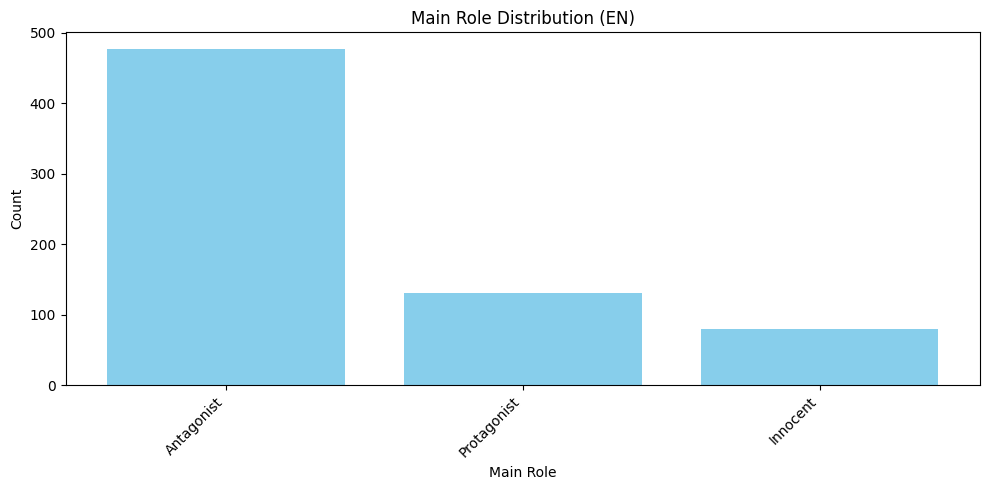

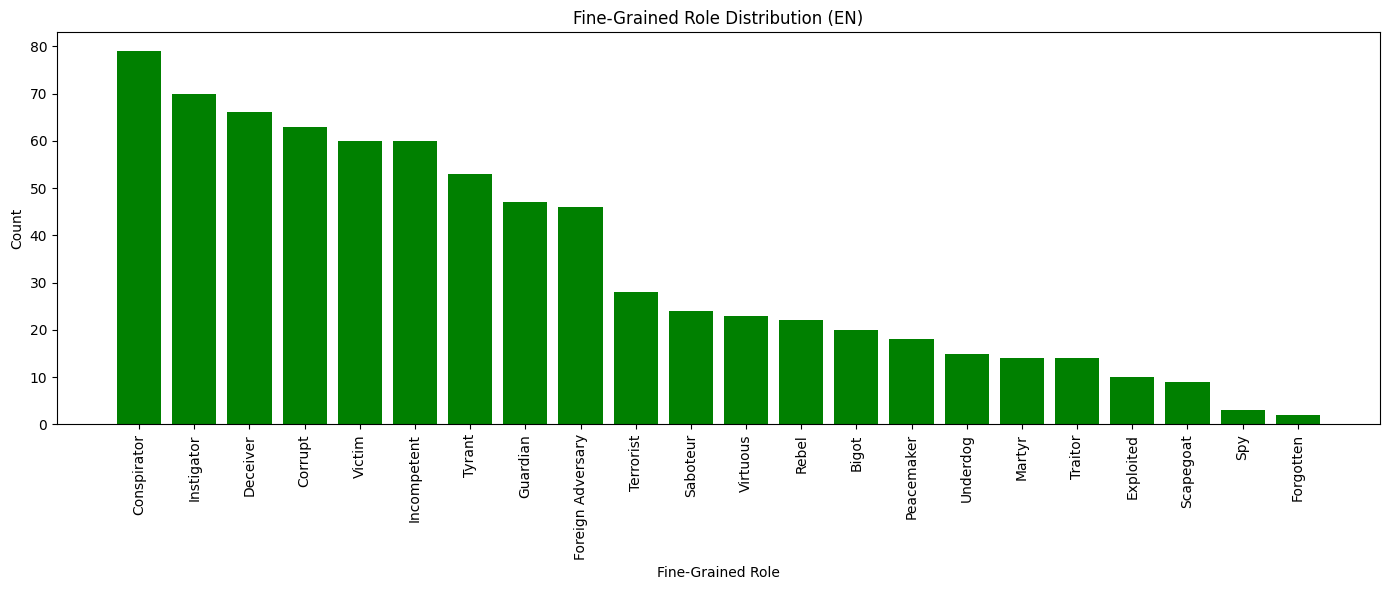

In [2]:
import os
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

def analyze_annotations(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        # doc_id               entity      start  end    MAIN ROLE      FineGrainedRoles
        # EN_CC_100013.txt    Bill Gates    93    102    Antagonist    Deceiver    Corrupt

    main_role_counts          = Counter()
    fine_grained_role_counts  = Counter()

    for line in lines:
        parts = line.strip().split('\t')    # remoes newline and slits based on tabs
        if len(parts) < 5:                  # safety check (malformed lines)
            continue                        # skip malformed lines
        main_role          = parts[4]
        fine_grained_roles = parts[5:]
        main_role_counts[main_role] += 1
        for role in fine_grained_roles:
            if role:                        # ignore empty tokens (safety check)
                fine_grained_role_counts[role] += 1

    # Convert results into DataFrames
    role_data = pd.DataFrame({
        'Main Role': list(main_role_counts.keys()),
        'Count':     list(main_role_counts.values())
    }).sort_values('Count', ascending=False)

    fine_grained_data = pd.DataFrame({
        'Fine-Grained Role': list(fine_grained_role_counts.keys()),
        'Count':             list(fine_grained_role_counts.values())
    }).sort_values('Count', ascending=False)

    # main role distribution and fine role distribution returned
    return role_data, fine_grained_data


def visualize_distribution(role_data, fine_grained_data):
    # main roles
    plt.figure(figsize=(10, 5))
    plt.bar(role_data['Main Role'], role_data['Count'], color='skyblue')
    plt.title('Main Role Distribution (EN)')
    plt.xlabel('Main Role')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # fine-grained roles
    plt.figure(figsize=(14, 6))
    plt.bar(fine_grained_data['Fine-Grained Role'], fine_grained_data['Count'], color='green')
    plt.title('Fine-Grained Role Distribution (EN)')
    plt.xlabel('Fine-Grained Role')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


#  run on English training annotations only
print("Analysing:", TRAIN_ANNOTATIONS)
role_data, fine_grained_data = analyze_annotations(TRAIN_ANNOTATIONS)

print("\n ---- Main roles ---- ")
print(role_data.to_string(index=False))

print("\n ---- Fine-grained roles ----")
print(fine_grained_data.to_string(index=False))

visualize_distribution(role_data, fine_grained_data)

The analysis of the training annotations reveals a strong class imbalance in the dataset. At the main role level, the Antagonist category is by far the most frequent with 477 instances, followed by Protagonist (130) and Innocent (79), indicating a strong bias toward adversarial framing in the data. A similar imbalance is observed at the fine-grained level, where Conspirator (79), Instigator (70), Deceiver (66), and Corrupt (63) are among the most common roles, while several categories such as Spy (3) and Forgotten (2) are extremely underrepresented.

This distribution suggests that models trained on this dataset may be **biased toward predicting antagonist-related** roles.

Entity Framing
---

In the following code snippets we'll produce an entity framing solution based on Natural Language Techniques studied.

In [3]:
#  0. Install / imports
!pip install spacy scikit-learn
!python -m spacy download en_core_web_md

import os, re
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, f1_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.linear_model  import LogisticRegression
from sklearn.multioutput   import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
import spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 50.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Data Overview and Structure

To begin, we need to define the data folders and parse the annotation and mention files based on their established structure. The dataset consists of several key files, detailed below:

### 1. Training Annotations (`training_annotations.txt`)
This file contains the ground truth labels for the training set, specifying the article ID, entity mention, its offsets, main role, and fine-grained roles. Each line represents an annotated entity.

**Example Rows:**
```
EN_CC_100013.txt	Bill Gates	93	102	Antagonist	Deceiver	Corrupt
EN_CC_100013.txt	BBC	1860	1862	Antagonist	Deceiver
EN_CC_100013.txt	Jeffrey Epstein	2005	2019	Antagonist	Corrupt
EN_UA_300009.txt	Fail Alsynov	176	187	Protagonist	Rebel	Martyr
```

### 2. Raw Training Documents (`raw-documents` directory)
This directory contains the full text of the news articles corresponding to the `article_id`s found in the annotation files. Each file in this directory represents a single news article.

**Example Content (from a raw document):**
```
Pentagon plans to serve LAB-GROWN MEAT to troops in the name of climate change

The Washington Free Beacon reported that BioMADE, a public-private partnership that has received more than $500 million from the DoD, is responsible for the endeavor. BioMADE announced on its website on June 3 that it is looking for new ideas to reduce the CO2 emissions from food production and transport at military sites. These ideas include "novel cell culture methods suitable for the production of cultivated meat or protein" - essentially a euphemism for lab-grown fake meat.
```

### 3. Test Entity Mentions (`test_entity_mentions.txt`)
This file lists entity mentions in the test set that require role assignment. It provides the article ID, the entity mention text, and its start and end offsets within the document.

**Example Rows:**
```
EN_UA_DEV_100012.txt	Washington	1441	1450
EN_UA_DEV_100012.txt	Americans	2397	2405
EN_CC_200053.txt	Rishi Sunak	85	95
EN_CC_200040.txt	Extinction Rebellion	189	208
EN_CC_200070.txt	Eric Garcetti	89	101
EN_CC_200070.txt	Los Angeles	2313	2323
```

In [6]:
from google.colab import drive
drive.mount('/content/drive')

#  1. Paths
BASE              = '/content/drive/MyDrive/NLP_Project'
TRAIN_ANNOTATIONS = f'{BASE}/training/EN/subtask-1-annotations.txt'
TRAIN_DOCS_DIR    = f'{BASE}/training/EN/raw-documents'
TEST_MENTIONS     = f'{BASE}/test/EN/subtask-1-entity-mentions.txt'
TEST_DOCS_DIR     = f'{BASE}/test/EN/subtask-1-documents'
GOLD_FILE         = f'{BASE}/test/EN/subtask-1-annotations.txt'
OUTPUT_FILE       = f'{BASE}/predictions_subtask1_EN.txt'

nlp = spacy.load("en_core_web_md")

# 2. DATA LOADING
def parse_annotations(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 5:
                continue
            rows.append({
                'article_id':         parts[0],
                'entity_mention':     parts[1],
                'start_offset':       int(parts[2]),
                'end_offset':         int(parts[3]),
                'main_role':          parts[4],
                'fine_grained_roles': [r for r in parts[5:] if r],
            })
    return pd.DataFrame(rows)

def parse_mentions(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 4:
                continue
            rows.append({
                'article_id':     parts[0],
                'entity_mention': parts[1],
                'start_offset':   int(parts[2]),
                'end_offset':     int(parts[3]),
            })
    return pd.DataFrame(rows)

annotations = parse_annotations(TRAIN_ANNOTATIONS)
print(f"Loaded {len(annotations)} training annotations\n")


Mounted at /content/drive
Loaded 686 training annotations



Another important step is to Extract the Context responsible for extracting useful textual context around each entity mention.

Roles depend on context (not just entity name)
```
Example:
"Russia invaded Ukraine" --> Antagonist
"Russia signed agreement" --> could be neutral/protagonist
```


We'll use caching to efficiently load documents (fast access after first load), extract the relevant sentence context for a given entity mention, and then combine the spaCy word embeddings of the mention and its context to create a single feature vector.

A better solution uses the previous and next sentence (see get_window_context instead of using get_sentence_context).




In [28]:
# 3. CONTEXT EXTRACTION

CONTEXT = 300
_doc_cache  = {}    # Dictionary used to store loaded documents, to avoid reading same file multipe times

def load_doc(article_id, docs_dir):
    if article_id not in _doc_cache:                # Check if document is already cached (skip reading from disk)
        path = os.path.join(docs_dir, article_id)   # /training/EN/raw-documents/EN_CC_100013.txt
        with open(path, encoding='utf-8') as f:
            _doc_cache[article_id] = f.read()       # store in cache
    return _doc_cache[article_id]

def get_sentence_context(text, start, end):
    '''
    Extracts the sentence where the entity appears.
    Parameters:
        - Text: full article
        - Start: entity start character index
        - End: entity end character index
    '''
    doc = nlp(text)
    for sent in doc.sents:
        if sent.start_char <= start < sent.end_char:    # Check if entity start position is within sentence boundaries (Ex. Sentence: "Russia invaded Ukraine in 2022." Entity: "Russia")
            return sent.text.strip()                    # Return the full sentence containing the entity.
    return text[max(0, start - CONTEXT): end + CONTEXT].strip()   # fallback window (take +/- 300 characters around entity)


def get_window_context(text, start, end, window=1):
    """
    Extracts a window of sentences around the entity mention.
    Parameters:
        - text  : full article
        - start : entity start character index
        - end   : entity end character index
        - window: number of sentences before/after to include (default=1)
    Example with window=1:
        [prev sentence] [sentence containing entity] [next sentence]
    """
    doc   = nlp(text)
    sents = list(doc.sents)
    for i, sent in enumerate(sents):
        if sent.start_char <= start < sent.end_char:
            i_start = max(0, i - window)
            i_end   = min(len(sents), i + window + 1)
            return ' '.join(s.text for s in sents[i_start:i_end]).strip()
    # fallback: character window if no sentence boundary found
    return text[max(0, start - CONTEXT): end + CONTEXT].strip()


def get_entity_vector(mention_text, context_text):
    '''
    Builds a semantic vector combining entity name and surrounding context
    '''
    m_vec = nlp(mention_text).vector    # Get embedding of entity name (dimension of embedding is 300)
    c_vec = nlp(context_text).vector    # Get embedding of context sentence (dimension of embedding is 300)
    if np.linalg.norm(m_vec) == 0 and np.linalg.norm(c_vec) == 0:     # fallback is SpaCy vectors are empty
        return np.zeros(CONTEXT*2)  # since we concatenate m_vec and c_vec we have 300+300
    return np.concatenate([m_vec, c_vec])
    #return 0.6 * m_vec + 0.4 * c_vec



Considering each row in the annotations table, eximplified below,


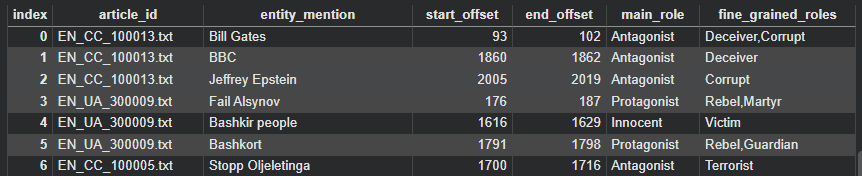


In [29]:
# 4. BUILD FEATURE MATRIX

print("\nBuilding feature vectors …")
vectors, main_labels, fine_labels_raw = [], [], []
# Vectors Will contain numerical representations of entities + context. Each vector = one training example.
# Main labels Stores main role labels.
# fine_labels_raw Stores fine-grained role lists.

# Iterate through annotations
for _, row in annotations.iterrows():
    text = load_doc(row['article_id'], TRAIN_DOCS_DIR)
    #ctx  = get_sentence_context(text, row['start_offset'], row['end_offset'])
    ctx  = get_window_context(text, row['start_offset'], row['end_offset'])
    vec  = get_entity_vector(row['entity_mention'], ctx)
    vectors.append(vec)
    main_labels.append(row['main_role'])
    fine_labels_raw.append(row['fine_grained_roles'])

# Transforms list of vectors into matrix (number_of_samples, 2*embedding_dimension).
X = np.array(vectors)
print(f"Feature matrix: {X.shape}")


Building feature vectors …
Feature matrix: (686, 600)


In [30]:
# 5. LABEL ENCODING
# Machine learning models cannot work directly with strings, so we convert it in a numerical form

main_classes = sorted(set(main_labels))                     # ['Antagonist', 'Protagonist', 'Innocent']
main2idx     = {c: i for i, c in enumerate(main_classes)}   # create label (Antagonist: 0; Protagonist: 1; Innocent: 2)
idx2main     = {i: c for c, i in main2idx.items()}          # Reverse Mapping (0: Antagonist; 1: Protagonis; 2: Innocent)
y_main       = np.array([main2idx[l] for l in main_labels]) # Encode main labels

fine_classes = sorted(set(r for roles in fine_labels_raw for r in roles)) # This flattens all role lists ([ ['Corrupt', 'Deceiver'], ['Victim']] --> ['Corrupt', 'Deceiver', 'Victim'])
fine2idx     = {c: i for i, c in enumerate(fine_classes)}                 # FineRole index


def encode_fine(roles):
    '''
    Multi-label encoding function
    '''
    vec = np.zeros(len(fine_classes), dtype=int)
    for r in roles:
        if r in fine2idx:
            vec[fine2idx[r]] = 1      # Activate corresponding position (e.g. [1,1,0,0,0,...] -> Corrupt present and Deceiver present)
    return vec

y_fine = np.array([encode_fine(r) for r in fine_labels_raw])    # Transforms all labels into binary matrix.

print(f"Main classes     : {main_classes}")
print(f"Fine-grained     : {len(fine_classes)} classes")

Main classes     : ['Antagonist', 'Innocent', 'Protagonist']
Fine-grained     : 22 classes


We split training data temporarily just to compare methods fairly.
Once best method is selected, we RETRAIN on the full training set
before running inference on the real test set.

In [31]:

# 6. TRAIN / VAL SPLIT
X_train, X_val, ym_train, ym_val, yf_train, yf_val = train_test_split(
    X, y_main, y_fine, test_size=0.2, random_state=42, stratify=y_main
)


We apply different classifiers in order to find the best classifier and use it as final choice.

In [32]:
import numpy as np
from sklearn.metrics import (classification_report, f1_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import LinearSVC
from sklearn.multioutput     import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.calibration     import CalibratedClassifierCV


# 7. CLASSIFIERS - two variants for the comparison table

# helper: exact match ratio for multi-label
def exact_match_ratio_official(yf_true, yf_pred):
    """Mirrors the official scorer: exact match on fine-grained labels only."""
    return float(np.mean(np.all(yf_true == yf_pred, axis=1)))

#  helper: run one configuration and return metrics dict
def run_experiment(name, main_pipeline, fine_pipeline,
                   Xtr, ymtr, yftr, Xv, ymv, yfv):
    """
    Trains main + fine-grained pipelines, evaluates on validation set,
    returns metrics dict matching the official scorer output exactly:
        EMR | micro_Prec | micro_Rec | micro_F1 | main_Acc
    """
    #  main role (multi-class)
    main_pipeline.fit(Xtr, ymtr)
    ym_pred = main_pipeline.predict(Xv)

    # ine-grained: skip all-zero columns in this split (avoids LR error)
    col_has_pos = yftr.sum(axis=0) > 0               # (n_fine_classes,) bool
    valid_cols  = np.where(col_has_pos)[0]

    yftr_sub = yftr[:, valid_cols]
    yfv_sub  = yfv[:,  valid_cols]

    fine_pipeline.fit(Xtr, yftr_sub)
    yf_pred_sub = fine_pipeline.predict(Xv)

    # reconstruct full-dimension prediction (zeros for unseen classes)
    yf_pred = np.zeros_like(yfv, dtype=int)
    yf_pred[:, valid_cols] = yf_pred_sub

    #  metrics (all on fine-grained full dimension)
    emr  = exact_match_ratio_official(yfv, yf_pred)
    prec = precision_score(yfv, yf_pred, average='micro', zero_division=1)
    rec  = recall_score(   yfv, yf_pred, average='micro', zero_division=1)
    f1   = f1_score(       yfv, yf_pred, average='micro', zero_division=1)
    acc  = accuracy_score( ymv, ym_pred)

    return {
        'name':       name,
        'main_clf':   main_pipeline,
        'fine_clf':   fine_pipeline,
        'valid_cols': valid_cols,      # needed at inference time
        'ym_pred':    ym_pred,
        'yf_pred':    yf_pred,
        'EMR':  round(emr,  4),
        'Prec': round(prec, 4),
        'Rec':  round(rec,  4),
        'F1':   round(f1,   4),
        'Acc':  round(acc,  4),
    }


In [33]:
#  A: Baseline LR - no imbalance handling
resA = run_experiment(
    "LR Baseline",
    Pipeline([('sc', StandardScaler()),
              ('clf', LogisticRegression(max_iter=1000, solver='lbfgs',
                                        multi_class='multinomial'))]),
    Pipeline([('sc', StandardScaler()),
              ('clf', MultiOutputClassifier(
                  LogisticRegression(max_iter=1000)))]),
    X_train, ym_train, yf_train, X_val, ym_val, yf_val
)

#  B: LR balanced
resB = run_experiment(
    "LR Balanced",
    Pipeline([('sc', StandardScaler()),
              ('clf', LogisticRegression(max_iter=1000, solver='lbfgs',
                                        multi_class='multinomial',
                                        class_weight='balanced'))]),
    Pipeline([('sc', StandardScaler()),
              ('clf', MultiOutputClassifier(
                  LogisticRegression(max_iter=1000,
                                     class_weight='balanced')))]),
    X_train, ym_train, yf_train, X_val, ym_val, yf_val
)

#  C: LR balanced + lower regularisation
resC = run_experiment(
    "LR Balanced C=5",
    Pipeline([('sc', StandardScaler()),
              ('clf', LogisticRegression(max_iter=2000, solver='lbfgs',
                                        multi_class='multinomial',
                                        class_weight='balanced', C=5.0))]),
    Pipeline([('sc', StandardScaler()),
              ('clf', MultiOutputClassifier(
                  LogisticRegression(max_iter=2000,
                                     class_weight='balanced', C=5.0)))]),
    X_train, ym_train, yf_train, X_val, ym_val, yf_val
)

#  D: Linear SVM (great for high-dim sparse/dense text features) ─
# CalibratedClassifierCV wraps LinearSVC to enable predict_proba if needed
resD = run_experiment(
    "LinearSVM Balanced",
    Pipeline([('sc', StandardScaler()),
              ('clf', CalibratedClassifierCV(
                  LinearSVC(max_iter=2000, class_weight='balanced', C=1.0)))]),
    Pipeline([('sc', StandardScaler()),
              ('clf', MultiOutputClassifier(
                  CalibratedClassifierCV(
                      LinearSVC(max_iter=2000, class_weight='balanced'))))]),
    X_train, ym_train, yf_train, X_val, ym_val, yf_val
)

#  E: Random Forest (non-linear, handles imbalance via class_weight) ─
resE = run_experiment(
    "Random Forest Balanced",
    Pipeline([('clf', RandomForestClassifier(n_estimators=200, random_state=42,
                                             class_weight='balanced',
                                             n_jobs=-1))]),
    Pipeline([('clf', MultiOutputClassifier(
                  RandomForestClassifier(n_estimators=200, random_state=42,
                                         class_weight='balanced',
                                         n_jobs=-1)))]),
    X_train, ym_train, yf_train, X_val, ym_val, yf_val
)

#  F: Gradient Boosting (strong on tabular/embedding features) ─
resF = run_experiment(
    "Gradient Boosting",
    Pipeline([('sc', StandardScaler()),
              ('clf', GradientBoostingClassifier(n_estimators=100,
                                                 learning_rate=0.1,
                                                 random_state=42))]),
    Pipeline([('sc', StandardScaler()),
              ('clf', MultiOutputClassifier(
                  GradientBoostingClassifier(n_estimators=100,
                                             learning_rate=0.1,
                                             random_state=42)))]),
    X_train, ym_train, yf_train, X_val, ym_val, yf_val
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of itera

In [34]:
# 8. EVALUATION

BASELINES = [
    {"name": "Majority baseline", "EMR": 0.0659, "Prec": 0.0989, "Rec": 0.0900, "F1": 0.0942, "Acc": 0.8022},
    {"name": "Random baseline",   "EMR": 0.0220, "Prec": 0.0330, "Rec": 0.0300, "F1": 0.0314, "Acc": 0.2418},
]

results = [resA, resB, resC, resD, resE, resF]

header = f"{'METHOD':<28} {'EMR':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Acc':>7}"
sep    = "─" * len(header)
print(f"\nCOMPARISON - EN\n{sep}\n{header}\n{sep}")
for r in BASELINES:
    print(f"{r['name']:<28} {r['EMR']:>7.4f} {r['Prec']:>7.4f} "
          f"{r['Rec']:>7.4f} {r['F1']:>7.4f} {r['Acc']:>7.4f}")
print(sep)
for r in results:
    print(f"{r['name']:<28} {r['EMR']:>7.4f} {r['Prec']:>7.4f} "
          f"{r['Rec']:>7.4f} {r['F1']:>7.4f} {r['Acc']:>7.4f}")
print(sep)

#  select best by micro-F1 (matches official scorer)
best = max(results, key=lambda r: r['F1'])
print(f"\n> Best method : {best['name']}  (micro-F1={best['F1']:.4f})\n")

#  per-class breakdown for best model ─
print(" Main Role Report (best model) ")
print(classification_report(ym_val, best['ym_pred'],
                             target_names=main_classes, zero_division=0))
print(" Fine-Grained Report (best model) ")
print(classification_report(yf_val, best['yf_pred'],
                             target_names=fine_classes, zero_division=0))


COMPARISON - EN
────────────────────────────────────────────────────────────────────
METHOD                           EMR    Prec     Rec      F1     Acc
────────────────────────────────────────────────────────────────────
Majority baseline             0.0659  0.0989  0.0900  0.0942  0.8022
Random baseline               0.0220  0.0330  0.0300  0.0314  0.2418
────────────────────────────────────────────────────────────────────
LR Baseline                   0.1667  0.2880  0.2432  0.2637  0.6087
LR Balanced                   0.1377  0.2388  0.3243  0.2751  0.5870
LR Balanced C=5               0.1522  0.2451  0.3378  0.2841  0.5725
LinearSVM Balanced            0.0072  1.0000  0.0068  0.0134  0.6957
Random Forest Balanced        0.0290  0.3636  0.0270  0.0503  0.6957
Gradient Boosting             0.1159  0.3182  0.1419  0.1963  0.7101
────────────────────────────────────────────────────────────────────

> Best method : LR Balanced C=5  (micro-F1=0.2841)

 Main Role Report (best model) 
 

In [35]:
#  9. INFERENCE ON TEST SET  -> TSV output ─

test_df = parse_mentions(TEST_MENTIONS)
print(f"Test mentions: {len(test_df)}")

test_vectors = []
for _, row in test_df.iterrows():
    text = load_doc(row['article_id'], TEST_DOCS_DIR)
    #ctx  = get_sentence_context(text, row['start_offset'], row['end_offset'])
    ctx  = get_window_context(text, row['start_offset'], row['end_offset'])
    vec  = get_entity_vector(row['entity_mention'], ctx)
    test_vectors.append(vec)

X_test = np.array(test_vectors)

#  Retrain best method on FULL training data ─
best_main_clf = best['main_clf']
best_fine_clf = best['fine_clf']

best_main_clf.fit(X, y_main)

# Recompute valid_cols on the FULL training set (may differ from the 80% split)
full_valid_cols = np.where(y_fine.sum(axis=0) > 0)[0]
best_fine_clf.fit(X, y_fine[:, full_valid_cols])

#  Predict ─
pred_main    = best_main_clf.predict(X_test)
pred_fine_sub = best_fine_clf.predict(X_test)

# Reconstruct full dimension (zeros for classes absent in training)
pred_fine = np.zeros((len(X_test), len(fine_classes)), dtype=int)
pred_fine[:, full_valid_cols] = pred_fine_sub

#  Write TSV
with open(OUTPUT_FILE, 'w', encoding='utf-8') as out:
    for i, (_, row) in enumerate(test_df.iterrows()):
        main_str   = idx2main[pred_main[i]]
        fine_roles = [fine_classes[j]
                      for j, v in enumerate(pred_fine[i]) if v == 1]

        # fallback: if nothing predicted, use most common fine role
        # seen in training for this main role
        if not fine_roles:
            candidates = [
                r for roles, m in zip(fine_labels_raw, main_labels)
                for r in roles if m == main_str
            ]
            fine_roles = [Counter(candidates).most_common(1)[0][0]] \
                         if candidates else [main_str]

        line = '\t'.join([
            row['article_id'],
            row['entity_mention'],
            str(row['start_offset']),
            str(row['end_offset']),
            main_str,
            '\t'.join(fine_roles),
        ])
        out.write(line + '\n')

print(f"Predictions written ->{OUTPUT_FILE}")

#  Preview first 7 lines ─
print("\nSample output:")
with open(OUTPUT_FILE, encoding='utf-8') as f:
    for line in f.readlines()[:7]:
        print(line, end='')


#  Evaluate EMR against gold file
gold_annotations = parse_annotations(GOLD_FILE)
gold_lookup = {
    (r['article_id'], r['entity_mention'],
     str(r['start_offset']), str(r['end_offset'])): r['fine_grained_roles']
    for _, r in gold_annotations.iterrows()
}

exact_matches = 0
total = 0
for _, row in test_df.iterrows():
    key = (row['article_id'], row['entity_mention'],
           str(row['start_offset']), str(row['end_offset']))
    if key not in gold_lookup:
        continue
    i = test_df.index.get_loc(_)
    pred_roles = set(fine_classes[j]
                     for j, v in enumerate(pred_fine[test_df.index.get_loc(_)])
                     if v == 1)
    gold_roles = set(gold_lookup[key])
    if pred_roles == gold_roles:
        exact_matches += 1
    total += 1

emr = exact_matches / total if total > 0 else 0.0
print(f"\nEMR on test set : {emr:.4f}  ({exact_matches}/{total} exact matches)")
print(f"(Best method    : {best['name']})")



Test mentions: 91


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Predictions written ->/content/drive/MyDrive/NLP_Project/predictions_subtask1_EN.txt

Sample output:
EN_UA_DEV_100012.txt	Washington	1441	1450	Protagonist	Conspirator
EN_UA_DEV_100012.txt	Americans	2397	2405	Antagonist	Conspirator	Saboteur	Terrorist
EN_CC_200053.txt	Rishi Sunak	85	95	Protagonist	Bigot	Guardian	Underdog
EN_CC_200040.txt	Extinction Rebellion	189	208	Antagonist	Conspirator	Martyr
EN_CC_200070.txt	Eric Garcetti	89	101	Protagonist	Virtuous
EN_CC_200070.txt	Los Angeles	2313	2323	Antagonist	Conspirator
EN_UA_DEV_100033.txt	Russia	114	119	Innocent	Foreign Adversary

EMR on test set : 0.0879  (8/91 exact matches)
(Best method    : LR Balanced C=5)


Let's save the created models for reproducibility:

In [36]:
#  10. SAVE BEST MODEL
import joblib

MODEL_DIR = f'{BASE}/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save pipelines
joblib.dump(best['main_clf'],  f'{MODEL_DIR}/main_clf.pkl')
joblib.dump(best['fine_clf'],  f'{MODEL_DIR}/fine_clf.pkl')

# Save encoders (needed to decode predictions)
joblib.dump({
    'main2idx':      main2idx,
    'idx2main':      idx2main,
    'main_classes':  main_classes,
    'fine_classes':  fine_classes,
    'fine2idx':      fine2idx,
    'valid_cols':    best['valid_cols'],
    'best_method':   best['name'],
}, f'{MODEL_DIR}/encoders.pkl')

print(f"Saved: main_clf.pkl")
print(f"Saved: fine_clf.pkl")
print(f"Saved: encoders.pkl")
print(f"Best method: {best['name']}  (micro-F1={best['F1']:.4f})")

Saved: main_clf.pkl
Saved: fine_clf.pkl
Saved: encoders.pkl
Best method: LR Balanced C=5  (micro-F1=0.2841)


To recover the models for further use it is needed to run the following code snippet:

In [37]:
#  LOAD MODEL
import joblib

MODEL_DIR = f'{BASE}/models'

main_clf = joblib.load(f'{MODEL_DIR}/main_clf.pkl')
fine_clf = joblib.load(f'{MODEL_DIR}/fine_clf.pkl')
enc      = joblib.load(f'{MODEL_DIR}/encoders.pkl')

main2idx     = enc['main2idx']
idx2main     = enc['idx2main']
main_classes = enc['main_classes']
fine_classes = enc['fine_classes']
fine2idx     = enc['fine2idx']
valid_cols   = enc['valid_cols']

print(f" Loaded: {enc['best_method']}  (micro-F1 at save time: see comparison table)")

 Loaded: LR Balanced C=5  (micro-F1 at save time: see comparison table)




> ***NLP Case Study - Subtask_1 | Manuel Carlucci | Mtr: 855237 | m.carlucci69@studenti.uniba.it***

